# Real Estate Price Prediction (Feature Engineering)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("data\Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [15]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

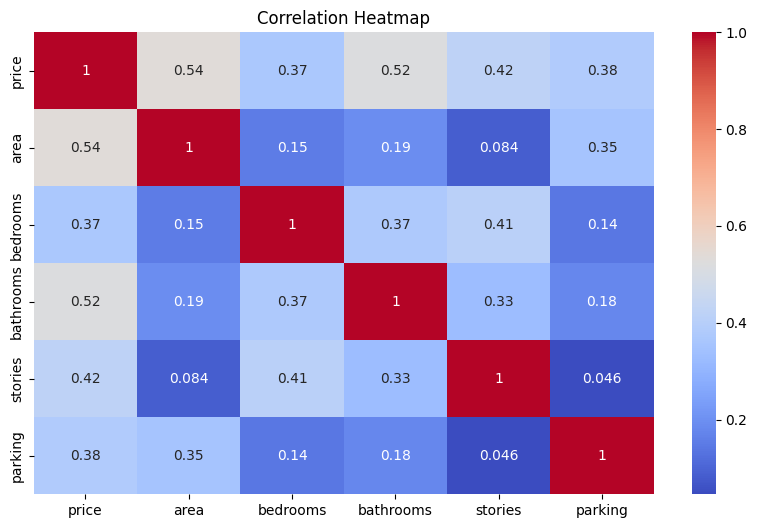

In [16]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

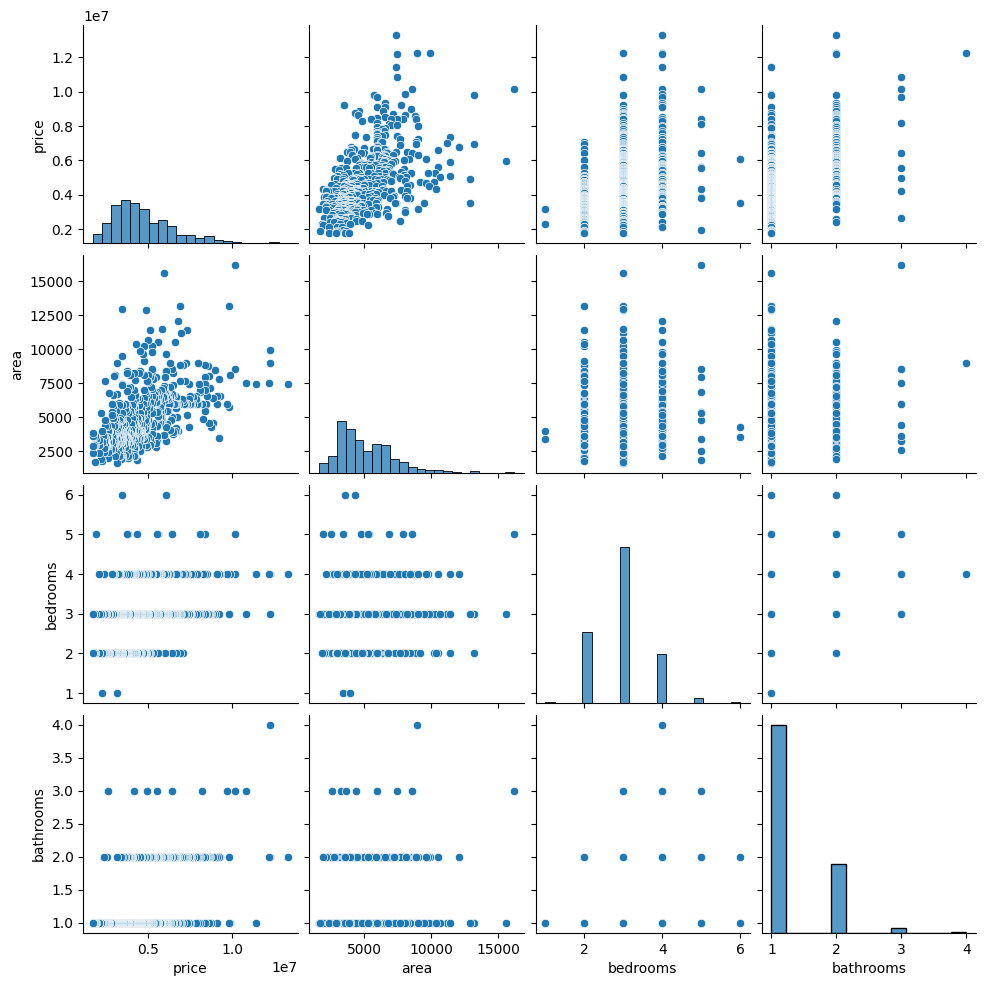

In [17]:
sns.pairplot(df[['price','area','bedrooms','bathrooms']])
plt.show()

In [18]:
# Numerical
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical
cat_cols = df.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [19]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes':1, 'no':0})

In [20]:
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

In [21]:
X = df.drop("price", axis=1)
y = df["price"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import pandas as pd

def calculate_vif(X):
    X = X.copy()

    # 1. Keep only numeric columns
    X = X.select_dtypes(include=[np.number])

    # 2. Convert everything to float
    X = X.astype(float)

    # 3. Remove NaN and Inf
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.dropna()

    # 4. Reset index (important for alignment)
    X = X.reset_index(drop=True)

    vif = pd.DataFrame()
    vif["Feature"] = X.columns
    vif["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    return vif


# Run VIF
vif_df = calculate_vif(X_train)
vif_df.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,bedrooms,15.634560
2,bathrooms,10.061551
3,stories,7.962876
0,area,7.962103
4,mainroad,6.873218
6,basement,2.103027
9,parking,1.942892
8,airconditioning,1.778698
5,guestroom,1.530698
10,prefarea,1.483164


In [26]:
high_vif = vif_df[vif_df["VIF"] > 10]["Feature"]

print("Removing:", list(high_vif))

X_train = X_train.drop(columns=high_vif, errors='ignore')
X_test = X_test.drop(columns=high_vif, errors='ignore')

Removing: ['bedrooms', 'bathrooms']


In [27]:
from sklearn.linear_model import LinearRegression

# Find best correlated feature
corr = pd.concat([X_train, y_train], axis=1).corr()["price"].abs().sort_values(ascending=False)
best_feature = corr.index[1]

print("Best Feature:", best_feature)

X_train_s = X_train[[best_feature]]
X_test_s = X_test[[best_feature]]

simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

y_pred_s = simple_model.predict(X_test_s)

Best Feature: area


In [28]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

y_pred_m = multi_model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

print("Simple LR:", evaluate(y_test, y_pred_s))
print("Multiple LR:", evaluate(y_test, y_pred_m))

Simple LR: (1474748.1337969352, 1917103.7021424233, 0.27287851871974644)
Multiple LR: (980355.6199304892, 1385286.3255326608, 0.6203399873431683)


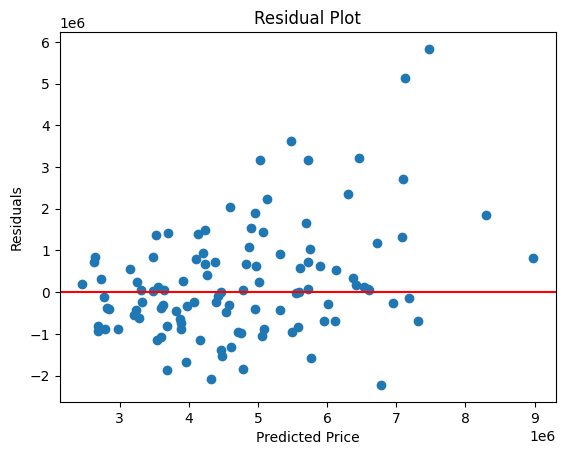

In [30]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_m

plt.scatter(y_pred_m, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

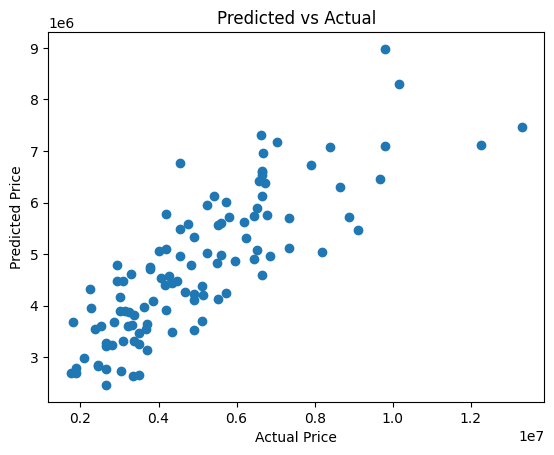

In [31]:
plt.scatter(y_test, y_pred_m)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()

In [32]:
coeff_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": multi_model.coef_
})

coeff_df = coeff_df.sort_values(by="Coefficient", key=abs, ascending=False)

print(coeff_df.head(10))

                            Feature    Coefficient
6                   airconditioning  861227.354891
5                   hotwaterheating  770152.311102
1                           stories  623891.082928
8                          prefarea  570463.776064
4                          basement  558169.085794
10     furnishingstatus_unfurnished -457798.349453
7                           parking  304608.034854
2                          mainroad  257216.824397
3                         guestroom  220946.347548
9   furnishingstatus_semi-furnished -109473.492838


In [33]:
print(vif_df.head(10))

           Feature        VIF
0             area   7.962103
1         bedrooms  15.634560
2        bathrooms  10.061551
3          stories   7.962876
4         mainroad   6.873218
5        guestroom   1.530698
6         basement   2.103027
7  hotwaterheating   1.091976
8  airconditioning   1.778698
9          parking   1.942892


In [34]:
simple_metrics = evaluate(y_test, y_pred_s)
multi_metrics = evaluate(y_test, y_pred_m)

comparison = pd.DataFrame({
    "Model": ["Simple LR", "Multiple LR"],
    "MAE": [simple_metrics[0], multi_metrics[0]],
    "RMSE": [simple_metrics[1], multi_metrics[1]],
    "R2": [simple_metrics[2], multi_metrics[2]]
})

print(comparison)

         Model           MAE          RMSE        R2
0    Simple LR  1.474748e+06  1.917104e+06  0.272879
1  Multiple LR  9.803556e+05  1.385286e+06  0.620340


## Final Observations

### 1. Most Influential Features
- Area has the highest impact on price
- Bathrooms and air conditioning also contribute significantly

### 2. Multicollinearity
- Features with high VIF (>10) indicate redundancy
- Removing them improves model stability

### 3. Feature Engineering Impact
- Encoding enabled categorical learning
- Removing multicollinearity improved performance
- Multiple Linear Regression performed better than Simple Linear Regression